In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds, get_ssp245_ds
import config # get standard variable names, settings for plotting, region bounds etc. 

In [2]:
## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [3]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))

## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(config.path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(config.path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## repeat for E3SM
ds_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(config.path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(config.path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK.load(), '15km':ds_HiLLA_15_UK.load()},
              'CESM':{'13km':ds_HiLLA_13_CE.load(), '15km':ds_HiLLA_15_CE.load()},
              'E3SM':{'13km':ds_HiLLA_13_E3.load(), '15km':ds_HiLLA_15_E3.load()}}

In [4]:
## repeat for the ssp245 runs
DS_ssp245_tas_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=config.ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=config.ens_mems_CE, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_tas_E3 =  set_time_to_center_of_bounds(xr.open_dataset(config.path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = ds_ssp245_tas_E3.sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_tas_UK.load(), 'CESM':DS_ssp245_tas_CE.load(), 'E3SM':DS_ssp245_tas_E3.load()}

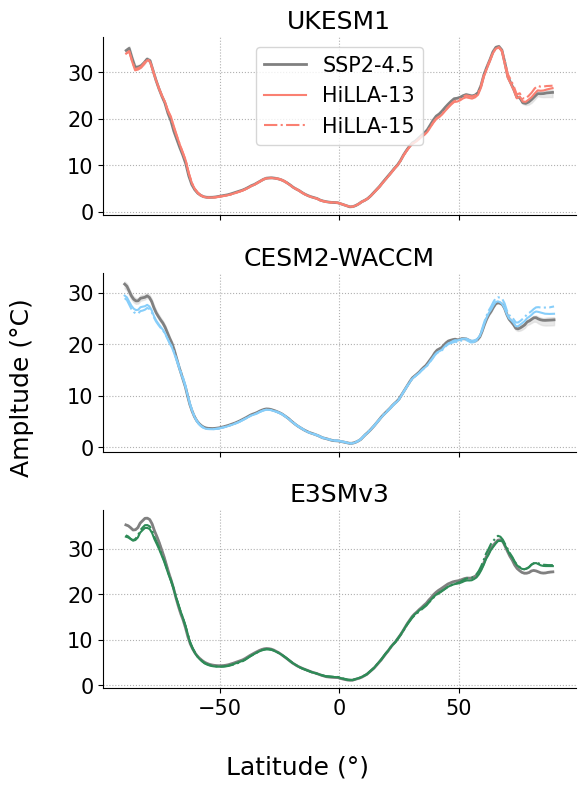

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

lss = {'13km':'solid', '15km':'dashdot'}

i=0
for model in config.models:
    ax = axs[i]
    # plot ssp245
    ds = SSP245_data[model]
    seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
    zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
    amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
    ensemble_mean_amplitude = amplitude.mean(dim='Ensemble_member')
    ensemble_min_amplitude = amplitude.min(dim='Ensemble_member')
    ensemble_max_amplitude = amplitude.max(dim='Ensemble_member')
    
    ax.fill_between(amplitude.latitude, ensemble_min_amplitude, ensemble_max_amplitude, color=config.colours['ssp245_light'], alpha=0.5)
    ax.plot(amplitude.latitude, ensemble_mean_amplitude, color=config.colours['ssp245'], linewidth=2, label='SSP2-4.5')
    
    # also plot hilla
    for alt in ['13km', '15km']:
        ds = HiLLA_data[model][alt]
        seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
        zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
        amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
        ax.plot(amplitude.latitude, amplitude, color=config.model_colors[model], linestyle=lss[alt], label='HiLLA-{}'.format(alt[0:2]))
            
    ax.set_title(config.model_names[model])
    ax.grid(ls='dotted')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1

axs[0].legend()

fig.supxlabel('Latitude (°)')
fig.supylabel('Ampltude (°C)')
plt.tight_layout()


plt.show()

In [6]:
### also get a recent baseline:
DS_hist_tas_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'CMIP',
                              scenario = 'historical', variable='tas', members=config.ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('1995', '2015')).rename({'y':'latitude', 'x':'longitude'})


DS_hist_tas_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'CMIP',
                              scenario = 'historical', variable='tas', members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], 
                              table='Amon', grid='gn').sel(time=slice('1995', '2015')).rename({'y':'latitude', 'x':'longitude'})


hist_data = {'UKESM':DS_hist_tas_UK.load(), 'CESM':DS_hist_tas_CE.load()}

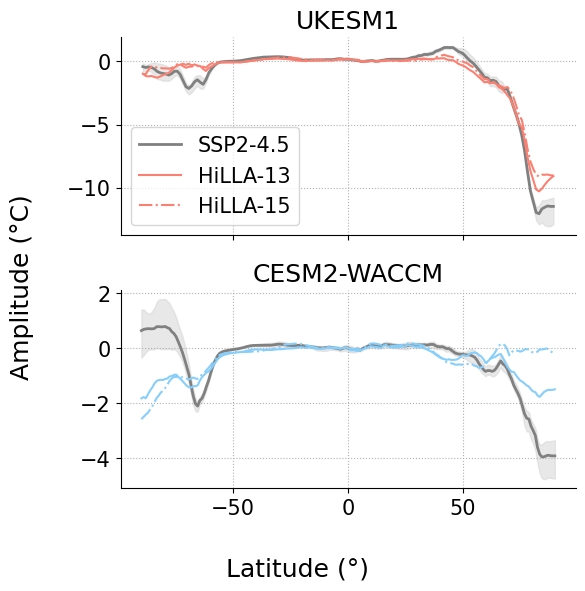

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

lss = {'13km':'solid', '15km':'dashdot'}

i=0
for model in ['UKESM', 'CESM']:
    ax = axs[i]
    base = hist_data[model]['tas'].groupby('time.month').mean(dim='time').mean(dim='longitude')
    base_amp = base.max(dim='month') - base.min(dim='month')
    # plot ssp245
    ds = SSP245_data[model].sel(time=slice('2050', '2069'))
    seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
    zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
    amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
    ensemble_mean_amplitude = amplitude.mean(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    ensemble_min_amplitude = amplitude.min(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    ensemble_max_amplitude = amplitude.max(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    
    ax.fill_between(amplitude.latitude, ensemble_min_amplitude, ensemble_max_amplitude, color=config.colours['ssp245_light'], alpha=0.5)
    ax.plot(amplitude.latitude, ensemble_mean_amplitude, color=config.colours['ssp245'], linewidth=2, label='SSP2-4.5')
    
    # also plot hilla
    for alt in ['13km', '15km']:
        ds = HiLLA_data[model][alt].sel(time=slice('2050', '2069'))
        seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
        zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
        amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
        ax.plot(amplitude.latitude, amplitude - base_amp.mean('Ensemble_member'), color=config.model_colors[model], linestyle=lss[alt], label='HiLLA-{}'.format(alt[0:2]))
            
    ax.set_title(config.model_names[model])
    ax.grid(ls='dotted')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1

axs[0].legend()

fig.supxlabel('Latitude (°)')
fig.supylabel('Amplitude (°C)')
plt.tight_layout()

plt.savefig('Figures/Seasonality_changes.jpg', dpi=300)
plt.show()

In [8]:
### next, plot interhemispheric temp. difference 

def IHTD(ds):
    IHTD = spatial_mean(ds, 'NH') - spatial_mean(ds, 'SH')
    annual_max = IHTD.groupby(IHTD.time.dt.year).max()
    annual_min = IHTD.groupby(IHTD.time.dt.year).min()
    annual_mean = IHTD.groupby(IHTD.time.dt.year).mean()
    return {'monthly_ts':IHTD, 
            'annual_mean':annual_mean, 
            'annual_max':annual_max, 
            'annual_min':annual_min,
            'annual_amp':annual_max - annual_min}


In [9]:
ds_HiLLA_13_CE

<xarray.Dataset> Size: 93MB
Dimensions:    (latitude: 192, longitude: 288, time: 420, nbnd: 2)
Coordinates:
  * latitude   (latitude) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * longitude  (longitude) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time       (time) object 3kB 2035-01-16 12:00:00 ... 2069-12-16 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    time_bnds  (time, nbnd) object 7kB 2035-01-01 00:00:00 ... 2070-01-01 00:...
    tas        (time, latitude, longitude) float32 93MB 248.0 248.0 ... 252.0
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS...
    logname:           walkerl
    host:              derecho1
    initial_file:      b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.001.c...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Tue Feb  4 11:52:07 2025: ncrcat -v TREFHT /glade/dere...
    NCO:               netCDF Operators version 5.2.6 (Homepage = http://nco....

In [10]:
IHTD_dict = IHTD(ds_HiLLA_13_CE)

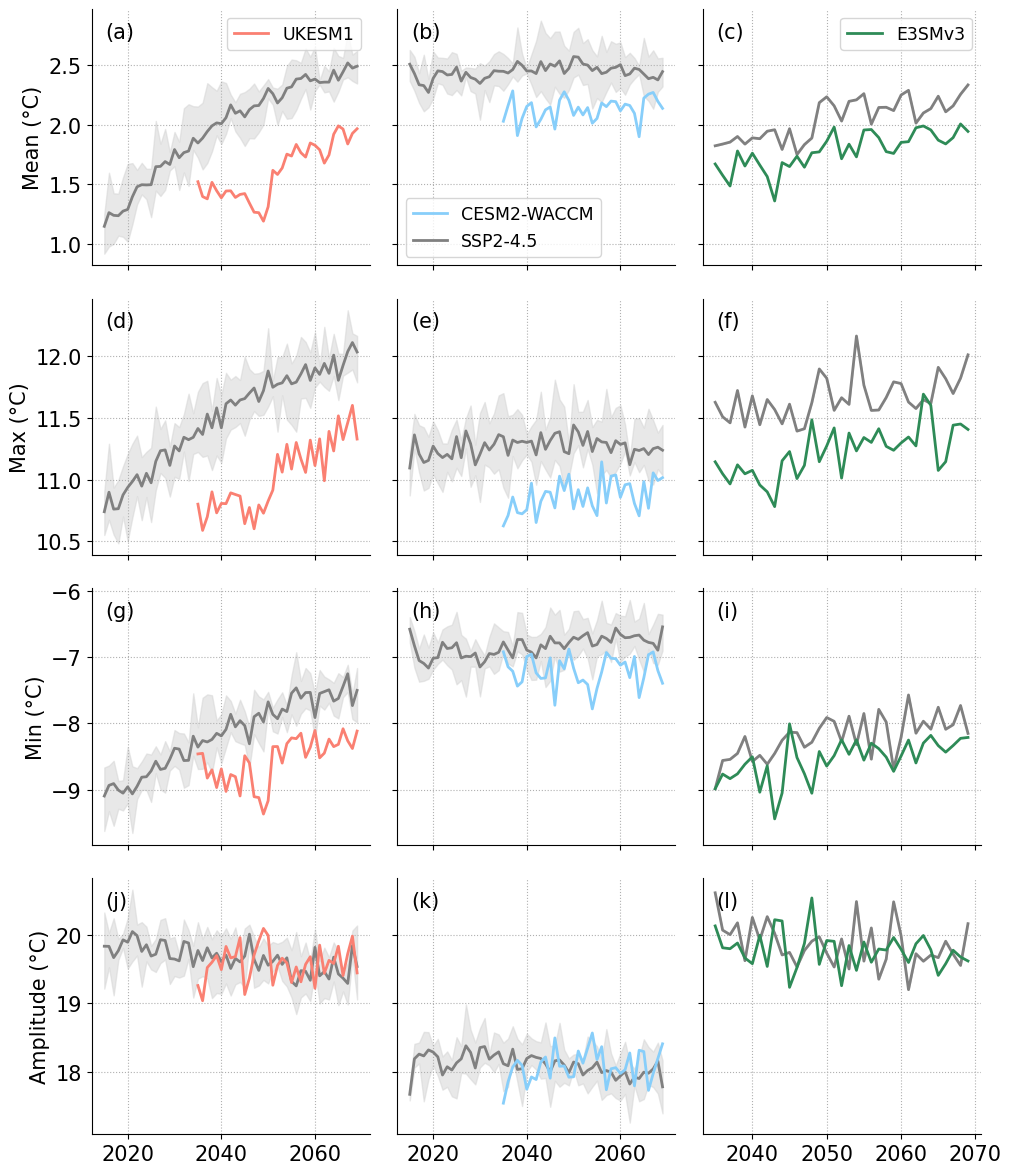

In [11]:
fig, axs = plt.subplots(4, 3, figsize=(10, 12), sharex='col', sharey='row')

#lss = {'13km':'solid', '15km':'dashdot'}
ylabs = ['Mean (°C)', 'Max (°C)', 'Min (°C)', 'Amplitude (°C)']
titles = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)", "(l)"]
i=0
for model in config.models:
    l=0
    for val in ['annual_mean', 'annual_max', 'annual_min', 'annual_amp']:
        ax = axs[l, i]
        IHTD_dict_ssp = IHTD(SSP245_data[model])
        IHTD_to_plot = IHTD_dict_ssp[val].tas
        ax.fill_between(IHTD_to_plot.year, IHTD_to_plot.min('Ensemble_member'), IHTD_to_plot.max('Ensemble_member'), color=config.colours['ssp245_light'], alpha=0.5)
        ax.plot(IHTD_to_plot.year, IHTD_to_plot.mean('Ensemble_member'), color=config.colours['ssp245'], linewidth=2)                     
        
        #for alt in ['13km', '15km']:
        IHTD_dict_HiLLA = IHTD(HiLLA_data[model][alt])
        IHTD_to_plot = IHTD_dict_HiLLA[val].tas
        ax.plot(IHTD_to_plot.year, IHTD_to_plot, linewidth=2, color=config.model_colors[model], label='{}'.format(config.model_names[model]))
        ax.grid(ls='dotted')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if i == 1:
            ax.plot([], [], color=config.colours['ssp245'], linewidth=2, label='SSP2-4.5')
        if i == 0:
            ax.set_ylabel(ylabs[l])
        if l == 0:
            ax.legend(fontsize='small')
        l=l+1
    i=i+1

k=0
for ax in axs.flatten():
    ax.text(x=0.05,y=0.95,s=titles[k],transform=ax.transAxes,ha='left',va='top',fontsize='medium')
    k=k+1

plt.tight_layout()
plt.savefig('Figures/IHTD_seasonal_cycle.jpg', dpi=350)